In [13]:
# -*- coding: utf-8 -*-
from __future__ import annotations   # <-- 무조건 최상단

from DATA.stock_invest_function import *
import pandas as pd
import numpy as np
import matplotlib
import pymysql
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


In [14]:
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host' : '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': 3307,              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

# ====== 0) DB 연결 ======
def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(
        url,
        pool_pre_ping=True,
        pool_recycle=1800,
        connect_args={
            "connect_timeout": 10,
            "read_timeout": 60,
            "write_timeout": 60,
        },
    )

engine = make_engine(db_info)

TABLE_NAME = "korea_monthly_trade_forecast_v2"

def make_pivot_from_trade_forecast_db(
    engine,
    forecast_dates: list,
    indicator: str,
    table_name: str = TABLE_NAME,
    aggfunc: str = "last"   # 중복 시 처리: "last" / "sum" 등
) -> pd.DataFrame:
    """
    forecast_dates(리스트) + indicator 조건으로 DB에서 데이터 조회 후
    index=date, columns=hs_code, values=value pivot 생성
    """

    if not forecast_dates:
        raise ValueError("forecast_dates 리스트가 비어 있습니다.")

    # MySQL IN 절용 placeholder 생성
    placeholders = ", ".join([f":d{i}" for i in range(len(forecast_dates))])
    params = {f"d{i}": forecast_dates[i] for i in range(len(forecast_dates))}
    params["indicator"] = indicator

    sql = text(f"""
        SELECT date, hs_code, value
        FROM {table_name}
        WHERE forecast_date IN ({placeholders})
          AND indicator = :indicator
    """)

    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params=params)

    if df.empty:
        raise ValueError("조건에 해당하는 데이터가 없습니다. forecast_dates/indicator를 확인하세요.")

    # 타입 정리
    df["date"] = pd.to_datetime(df["date"])
    df["hs_code"] = df["hs_code"].astype(str)

    # pivot
    pivot_df = (
        df.pivot_table(
            index="date",
            columns="hs_code",
            values="value",
            aggfunc=aggfunc  # 중복 시 마지막 값/합계 등 선택
        )
        .sort_index()
    )

    return pivot_df

import pandas as pd



# ====== 1) hs_code별 피벗 테이블 ======
def get_pivot_by_hscode(
    engine,
    hs_code: str,
    table: str = "korea_monthly_trade_forecast_v2",
    indicators: list[str] | None = None,
    use_latest_forecast_date: bool = True,
) -> pd.DataFrame:
    """
    - hs_code의 모든 row를 불러와서
      index=date, columns=indicator, values=value 형태의 피벗을 만듭니다.
    - 동일 key(date, hs_code, indicator)에 여러 행이 있으면 forecast_date가 최신인 것만 사용합니다.
    - indicators가 주어지면 해당 indicator만 포함합니다.
    """
    params = {"hs_code": hs_code}

    # 최신 forecast_date 선별 서브쿼리
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    # indicator 필터
    ind_filter = ""
    if indicators:
        # 안전한 바인딩을 위해 IN (:i0, :i1, ...)
        in_keys = []
        for i, ind in enumerate(indicators):
            key = f"i{i}"
            in_keys.append(f":{key}")
            params[key] = ind
        ind_filter = f"AND T.indicator IN ({', '.join(in_keys)})"

    sql = text(f"""
        SELECT
            CAST(T.date AS DATE) AS date,
            T.hs_code,
            T.indicator,
            T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code = :hs_code
        {ind_filter}
        ORDER BY date ASC
    """)
    df = pd.read_sql(sql, engine, params=params)
    if df.empty:
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    pv = df.pivot_table(index="date", columns="indicator", values="value", aggfunc="last").sort_index()
    pv.index.name = "date"
    return pv


# ====== 2) 두 날짜 사이 기간 변화 (절대/증감률) ======
def get_period_change(
    engine,
    date1: str,
    date2: str,
    hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
) -> dict:
    """
    - (date1, date2, hs_code, indicator)의 value를 비교해 절대/증감률 반환
    - 한쪽 날짜가 없어도 안전하게 처리하고, 어떤 날짜가 누락인지 note로 알려줍니다.
    """
    params = {"hs_code": hs_code, "indicator": indicator, "d1": date1, "d2": date2}

    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code   = :hs_code
          AND T.indicator = :indicator
          AND T.date IN (:d1, :d2)
        ORDER BY T.date
    """)
    df = pd.read_sql(sql, engine, params=params)

    # 안전 처리: 인덱스로 바꿔 dict처럼 조회
    out = {
        "hs_code": hs_code,
        "indicator": indicator,
        "date1": date1,
        "date2": date2,
        "value_date1": None,
        "value_date2": None,
        "abs_change": None,
        "pct_change": None,
        "note": None,
    }

    if df.empty:
        out["note"] = "두 날짜 모두 조회되지 않았습니다."
        return out

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    s = df.set_index("date")["value"]

    d1 = pd.to_datetime(date1).normalize()
    d2 = pd.to_datetime(date2).normalize()

    v1 = s.get(d1, None)
    v2 = s.get(d2, None)

    out["value_date1"] = float(v1) if v1 is not None else None
    out["value_date2"] = float(v2) if v2 is not None else None

    if (v1 is None) and (v2 is None):
        out["note"] = "두 날짜 모두 누락되었습니다."
        return out
    if v1 is None:
        out["note"] = f"{date1} 값이 없습니다."
        return out
    if v2 is None:
        out["note"] = f"{date2} 값이 없습니다."
        return out

    abs_chg = float(v2) - float(v1)
    pct_chg = None if float(v1) == 0 else abs_chg / float(v1)

    out["abs_change"] = abs_chg
    out["pct_change"] = pct_chg
    return out


# ====== 3) 12개월 YoY 성장률로 hs_code 랭킹 ======
def rank_hscodes_by_12m_yoy(
    engine,
    indicator: str,
    top_n: int = 10,
    as_of: str | None = None,  # 기준 월(없으면 테이블의 최신 월)
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
    drop_nonpositive_baseline: bool = False,  # 전년 값<=0이면 제외할지 옵션
) -> pd.DataFrame:
    """
    - 주어진 indicator에 대해 hs_code별로 최근(as_of) 월과 전년동월(as_of-12M)의 값을 비교해 YoY(%) 계산.
    - YoY = (value_t / value_t_12 - 1)
    - 기준월(as_of)이 None이면 테이블의 **최신 월**(전체 데이터 기준) 사용.
    - 결과: columns=[hs_code, as_of, prev_date, value_t, value_t_12, yoy_pct], yoy_pct 기준 내림차순 정렬 후 상위 top_n 반환.
    """
    # 3-1) 우선 해당 indicator의 전체 데이터(최신 forecast_date만) 로드
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.hs_code, T.value
        FROM {table} T
        {latest_join}
        WHERE T.indicator = :indicator
    """)
    df = pd.read_sql(sql, engine, params={"indicator": indicator})
    if df.empty:
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    df["date"] = pd.to_datetime(df["date"])

    # 3-2) 기준월(as_of) 결정: 전체 데이터에서 가장 최신 월
    if as_of is None:
        as_of_ts = df["date"].max().normalize()
    else:
        as_of_ts = pd.to_datetime(as_of).normalize()

    prev_ts = (as_of_ts + relativedelta(months=-12)).normalize()

    # 3-3) 피벗으로 빠르게 추출 (index=date, columns=hs_code, values=value)
    pv = df.pivot_table(index="date", columns="hs_code", values="value", aggfunc="last").sort_index()

    if as_of_ts not in pv.index or prev_ts not in pv.index:
        # 일부 월이 비어있을 수 있으니, 가장 가까운 월로 대체하고 싶다면 여기서 보간 가능
        # 지금은 엄격히 해당 월만 사용
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    v_t = pv.loc[as_of_ts]
    v_p = pv.loc[prev_ts]

    # 3-4) YoY 계산
    base = v_p.copy()
    if drop_nonpositive_baseline:
        base = base.where(base > 0)

    yoy = (v_t - base) / base
    res = pd.DataFrame({
        "hs_code": yoy.index,
        "as_of": as_of_ts.date(),
        "prev_date": prev_ts.date(),
        "value_t": v_t.values,
        "value_t_12": v_p.values,
        "yoy_pct": yoy.values
    }).dropna(subset=["yoy_pct"])

    res = res.sort_values("yoy_pct", ascending=False).head(top_n).reset_index(drop=True)
    return res

# ====== 4) 수출데이터 과거 기록 조회 ======
def get_trade_series_by_hscode_indicator(
    engine,
    root_hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_data"
) -> pd.DataFrame:
    """
    korea_monthly_trade_data 테이블에서 특정 root_hs_code와 indicator에 해당하는
    전체 value 시계열 데이터를 반환합니다.
    """
    sql = text(f"""
        SELECT
            CAST(date AS DATE) AS date,
            root_hs_code,
            indicator,
            value
        FROM {table}
        WHERE root_hs_code = :hs_code
          AND indicator = :indicator
        ORDER BY date ASC
    """)

    df = pd.read_sql(sql, engine, params={"hs_code": root_hs_code, "indicator": indicator})

    if df.empty:
        print(f"❗ 데이터가 없습니다: hs_code={root_hs_code}, indicator={indicator}")
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)
    return df

def combine_hist_and_forecast_continuous(
    hs_code: str,
    pv_forecast: pd.DataFrame,           # get_pivot_by_hscode(...) 결과 (index=date, columns=각 모델명)
    history_df: pd.DataFrame,            # get_trade_series_by_hscode_indicator(...) (index=date, cols=['root_hs_code','indicator','value'])
    history_value_col: str = "value",    # 실적 값 컬럼명
) -> pd.DataFrame:
    """
    출력: index=date, columns = ['hs_code'] + (pv_forecast.columns.tolist())
    - 과거 구간: 모든 예측 컬럼에 '실적(value)'을 복제해 채움
    - 미래 구간: 예측 데이터 그대로 사용
    - 중복 날짜에서는 '예측값 > 실적값' 우선 (예측이 비어 있으면 실적으로 대체)
    - expDlr 별도 칼럼 없이 예측 컬럼들만 연속 시계열이 되도록 구성
    """
    # 1) 정렬/타입 보정
    fcast = pv_forecast.copy()
    if not isinstance(fcast.index, pd.DatetimeIndex):
        fcast.index = pd.to_datetime(fcast.index)
    fcast = fcast.sort_index()

    hist = history_df.copy()
    if not isinstance(hist.index, pd.DatetimeIndex):
        hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()

    # 2) 예측 컬럼 리스트 자동 인식
    forecast_cols = fcast.columns.tolist()

    # 3) '실적(value)'을 예측 컬럼 이름들로 복제한 wide 데이터 만들기
    #    -> 과거 구간에서 각 모델 컬럼이 모두 실적값을 갖도록 함
    hist_series = hist[history_value_col].astype(float)
    hist_wide = pd.DataFrame(index=hist_series.index, data={
        c: hist_series for c in forecast_cols
    })

    # 4) 모델별 시계열을 결합
    #    - 같은 날짜에 둘 다 있으면 fcast(예측) 우선
    #    - 예측이 NaN인 곳은 실적(hist_wide)로 메움 -> NaN 방지
    combined_models = fcast.combine_first(hist_wide).sort_index()

    # 5) hs_code 컬럼 추가 및 정리
    combined_models.insert(0, "hs_code", hs_code)
    combined_models.index.name = "date"

    return combined_models


def _ensure_dt_index(df: pd.DataFrame) -> pd.DataFrame:
    """index를 DatetimeIndex로 통일하고 정렬"""
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.index)
    return out.sort_index()


# 1) 중심일 기준 n개월 전/후 합계와 증감률
def window_sum_change(
    combined_df: pd.DataFrame,
    hs_code: str,
    center_date: str,     # "YYYY-mm-dd"
    n_months: int,
    col: str,
    include_center: bool = False,
) -> dict:
    """
    중심일(center_date)을 기준으로 n개월 '이전' 합과 n개월 '이후' 합을 계산하고,
    (이후합-이전합)/이전합 을 pct_change로 반환.

    - include_center=False: 이전윈도우=(center-n, center) / 이후윈도우=(center, center+n]
      (center월 제외)
    - include_center=True:  이전윈도우=[center-n, center] / 이후윈도우=(center, center+n]
      (이전합에 center월 포함)
    """
    df = _ensure_dt_index(combined_df)
    df = df[df["hs_code"].astype(str) == str(hs_code)]

    if df.empty:
        return {"note": f"hs_code={hs_code} 데이터가 없습니다."}

    if col not in df.columns:
        return {"note": f"컬럼 '{col}' 이(가) 없습니다."}

    c = pd.to_datetime(center_date)
    start_prev = c - pd.DateOffset(months=n_months)
    end_prev   = c if include_center else c - pd.DateOffset(days=1)  # center 제외
    start_next = c + pd.DateOffset(days=1)  # center 제외
    end_next   = c + pd.DateOffset(months=n_months)

    prev_sum = df.loc[(df.index >= start_prev) & (df.index <= end_prev), col].sum(min_count=1)
    next_sum = df.loc[(df.index >= start_next) & (df.index <= end_next), col].sum(min_count=1)

    # 안전 처리
    prev_sum = np.nan if pd.isna(prev_sum) else float(prev_sum)
    next_sum = np.nan if pd.isna(next_sum) else float(next_sum)

    pct = None
    if prev_sum not in (None, 0, np.nan) and not pd.isna(prev_sum) and not pd.isna(next_sum):
        pct = (next_sum - prev_sum) / prev_sum

    return {
        "hs_code": str(hs_code),
        "column": col,
        "center_date": pd.to_datetime(center_date).date(),
        "n_months": n_months,
        "sum_prev": prev_sum,
        "sum_next": next_sum,
        "pct_change": pct,   # 0.12 = 12%
        "window_prev": [start_prev.date(), end_prev.date()],
        "window_next": [start_next.date(), end_next.date()],
        "include_center": include_center,
    }


# 2) n개월 전부터 전체 구간 라인플롯 (center_date 이후는 점선)
def plot_series_split_single_df(
    combined_df: pd.DataFrame,
    hs_code: str,
    split_date: str,
    n_months: int,
    value_col: str,                 # wide DF에서는 컬럼명(예: "1201" 또는 "854232" 등)
    date_col: str = "date",         # 기본은 "date"지만, 없으면 인덱스를 사용
    save_path: str | None = None,
    show: bool = True,
):
    """
    combined_df(실제+예측 결합)를 split_date 기준으로
    - split_date 이전(<=): 실선
    - split_date 이후(>):  점선
    으로 라인플롯.

    지원 형태:
    1) date_col 컬럼이 존재 -> 그걸 DatetimeIndex로 세팅
    2) date_col 컬럼이 없음 -> 이미 index가 날짜라고 가정하고 DatetimeIndex로 변환 시도
    """

    df = combined_df.copy()

    # ---- 1) 날짜 인덱스 만들기 (date 컬럼 있으면 우선 사용) ----
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        # date 컬럼이 없으면, index를 날짜로 간주
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

    # ---- 2) hs_code 필터 ----
    if "hs_code" not in df.columns:
        raise ValueError("combined_df에 'hs_code' 컬럼이 없습니다. (현재 구조를 확인하세요)")

    df = df[df["hs_code"].astype(str) == str(hs_code)]
    if df.empty:
        raise ValueError(f"hs_code={hs_code} 데이터가 없습니다.")

    # ---- 3) y값 컬럼 체크 ----
    if value_col not in df.columns:
        raise ValueError(
            f"컬럼 '{value_col}' 이(가) 없습니다. "
            f"가능한 컬럼 예: {list(df.columns[:20])} ..."
        )

    # ---- 4) 구간 자르기 ----
    c = pd.to_datetime(split_date)
    start = c - pd.DateOffset(months=n_months)

    sub = df.loc[df.index >= start, value_col].sort_index()
    left = sub.loc[sub.index <= c]
    right = sub.loc[sub.index > c]

    # ---- 5) Plot ----
    plt.figure(figsize=(10, 4.5))
    plt.plot(left.index, left.values, label=f"actual (<= {c.date()})")
    if not right.empty:
        plt.plot(right.index, right.values, linestyle="--", label=f"forecast (> {c.date()})")

    plt.axvline(c, linestyle=":", linewidth=1)
    plt.title(f"HS {hs_code} • {value_col} | from {start.date()} (split: {c.date()})")
    plt.xlabel("date")
    plt.ylabel(value_col)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


### forecast date  확인

def get_unique_forecast_dates(db_info, table_name="korea_monthly_trade_forecast_v2"):
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT DISTINCT forecast_date
        FROM {table_name}
        ORDER BY forecast_date
        """
        df = pd.read_sql(sql, conn)
    finally:
        conn.close()

    return df


In [17]:
## 예측한 날짜들 확인

forecast_dates_df = get_unique_forecast_dates(db_info)
print(forecast_dates_df)

  forecast_date
0    2025-10-31
1    2025-11-02
2    2025-11-03
3    2025-11-11
4    2025-11-12
5    2025-11-13
6    2025-12-09
7    2025-12-10
8    2025-12-12
9    2025-12-13


In [41]:
engine = make_engine(db_info)

forecast_dates = ["2025-12-12", "2025-12-13"]
indicator = "sarima_expDlr"

this_month_pivot_df = make_pivot_from_trade_forecast_db(
    engine=engine,
    forecast_dates=forecast_dates,
    indicator=indicator,
    aggfunc="last"
)

target_date = "2027-08-31"

# index가 datetime인 경우를 가정
target_date = pd.to_datetime(target_date)

# 해당 날짜에서 NaN인 컬럼 drop
this_month_df_filtered = this_month_pivot_df.loc[:, ~this_month_pivot_df.loc[target_date].isna()]

pv = this_month_df_filtered.loc['2025-10':]

pv['854232']

date
2025-10-31             NaN
2025-11-30             NaN
2025-12-31    1.105064e+10
2026-01-31    9.772243e+09
2026-02-28    1.012278e+10
2026-03-31    1.144964e+10
2026-04-30    1.059402e+10
2026-05-31    1.163905e+10
2026-06-30    1.270374e+10
2026-07-31    1.180984e+10
2026-08-31    1.236403e+10
2026-09-30    1.314320e+10
2026-10-31    1.253517e+10
2026-11-30    1.310977e+10
2026-12-31    1.397158e+10
2027-01-31    1.235906e+10
2027-02-28    1.258671e+10
2027-03-31    1.400543e+10
2027-04-30    1.310252e+10
2027-05-31    1.422778e+10
2027-06-30    1.523515e+10
2027-07-31    1.436875e+10
2027-08-31    1.498367e+10
2027-09-30    1.576020e+10
2027-10-31    1.517174e+10
2027-11-30    1.587788e+10
Name: 854232, dtype: float64

In [15]:
# with engine.connect() as conn:
#     print(conn.execute(text("SELECT 1")).scalar())

1


In [42]:
## 지난날 예측

forecast_dates = ["2025-11-12", "2025-11-13"]
indicator = "sarima_expDlr"

last_month_pivot_df = make_pivot_from_trade_forecast_db(
    engine=engine,
    forecast_dates=forecast_dates,
    indicator=indicator,
    aggfunc="last"
)

target_date = "2027-10-31"

# index가 datetime인 경우를 가정
target_date = pd.to_datetime(target_date)

# 해당 날짜에서 NaN인 컬럼 drop
last_month_df_filtered = last_month_pivot_df.loc[:, ~last_month_pivot_df.loc[target_date].isna()]
last_month_df_filtered.loc['2025-08-31':]['854232']

date
2025-08-31             NaN
2025-09-30             NaN
2025-10-31             NaN
2025-11-30    9.046898e+09
2025-12-31    9.741560e+09
2026-01-31    8.174686e+09
2026-02-28    8.314939e+09
2026-03-31    9.652466e+09
2026-04-30    8.721463e+09
2026-05-31    9.738258e+09
2026-06-30    1.065138e+10
2026-07-31    9.782411e+09
2026-08-31    1.034343e+10
2026-09-30    1.106119e+10
2026-10-31    1.044271e+10
2026-11-30    1.059461e+10
2026-12-31    1.128642e+10
2027-01-31    9.719546e+09
2027-02-28    9.859799e+09
2027-03-31    1.119733e+10
2027-04-30    1.026632e+10
2027-05-31    1.128312e+10
2027-06-30    1.219624e+10
2027-07-31    1.132727e+10
2027-08-31    1.188829e+10
2027-09-30    1.260605e+10
2027-10-31    1.198757e+10
Name: 854232, dtype: float64

In [39]:
# # 2) 두 날짜 사이 변화
# out = get_period_change(
#     engine,
#     date1="2025-10-31",
#     date2="2026-10-31",
#     hs_code="854232",
#     indicator="sarima_expDlr"  # 예: 스크린샷의 컬럼들 중 하나
# )
# print("\n[Period change]\n", out)


[Period change]
 {'hs_code': '854232', 'indicator': 'sarima_expDlr', 'date1': '2025-10-31', 'date2': '2026-10-31', 'value_date1': 8623063634.202923, 'value_date2': 10054396401.082748, 'abs_change': 1431332766.8798256, 'pct_change': 0.16598889067715103, 'note': None}


In [23]:
target_hscode = "854232"
split_date = "2025-11-30"

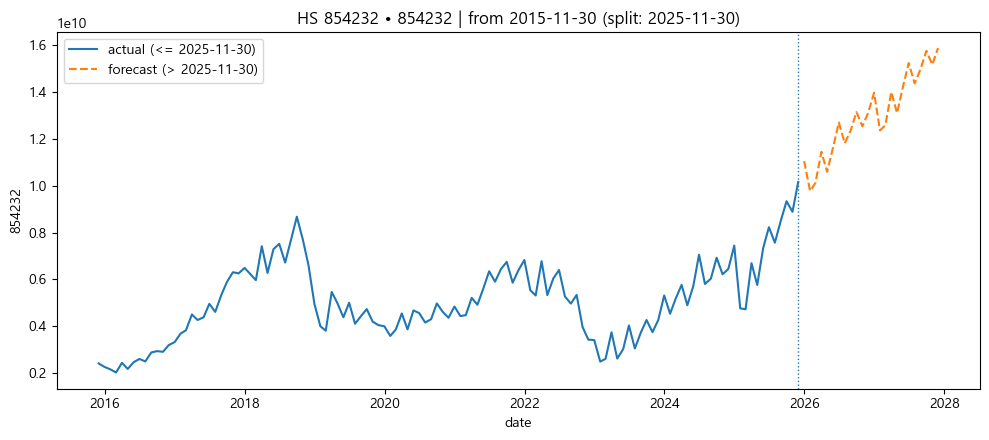

In [24]:
history_df = get_trade_series_by_hscode_indicator(
    engine,
    root_hs_code = target_hscode,
    indicator = "expDlr"
)

# 결합
combined_df = combine_hist_and_forecast_continuous(target_hscode, pv, history_df)

# # 1) 중심일 기준 전/후 합과 증감률
# res = window_sum_change(combined_df, hs_code=target_hscode,
#                         center_date=split_date, n_months=12, col= selected_method,
#                         include_center=False)

# 2) n개월 전부터 그려주고, 중심일 이후는 점선(예측)으로
plot_series_split_single_df(
    combined_df = combined_df,
    hs_code = target_hscode,
    split_date = split_date,
    n_months = 120,
    value_col=str(target_hscode),   # 컬럼명이 문자열이면 str로 맞춰주세요
)

In [26]:
history_df.tail(10)

,root_hs_code,indicator,value
date,,,
2025-02-28,854232,expDlr,4.725940e+09
2025-03-31,854232,expDlr,6.694280e+09
2025-04-30,854232,expDlr,5.761090e+09
2025-05-31,854232,expDlr,7.337390e+09
2025-06-30,854232,expDlr,8.230270e+09
2025-07-31,854232,expDlr,7.568270e+09
2025-08-31,854232,expDlr,8.504650e+09
2025-09-30,854232,expDlr,9.339170e+09
2025-10-31,854232,expDlr,8.886150e+09


#### 실제치와 예측치 비교



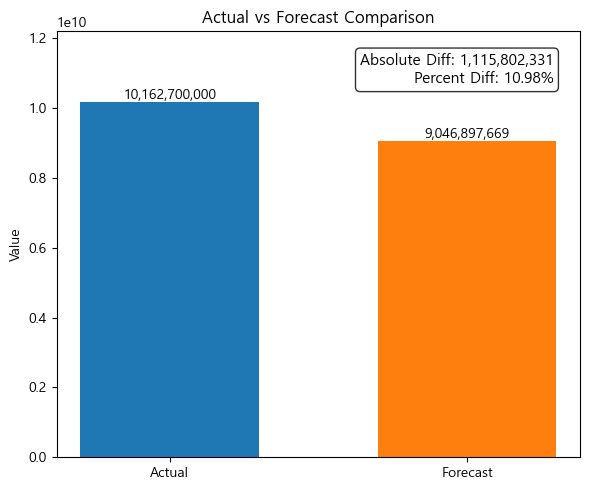

In [36]:
forecast = last_month_df_filtered.loc[split_date]['854232']
actual = history_df.iloc[-1]['value']

# 편차 계산
abs_diff = abs(actual - forecast)
pct_diff = abs_diff / actual * 100

# 그래프 데이터
labels = ['Actual', 'Forecast']
values = [actual, forecast]

# 그림 생성
plt.figure(figsize=(6, 5))
bars = plt.bar(
    labels,
    values,
    color=['#1f77b4', '#ff7f0e'],  # 대비 뚜렷한 파랑 / 주황
    width=0.6
)

# y축 단위 표시 (억 단위가 아니라 원 그대로)
plt.ylabel('Value')
plt.title('Actual vs Forecast Comparison')

# ✅ y축 상단 확장 (중요)
y_max = max(values)
plt.ylim(0, y_max * 1.2)

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# 편차 텍스트 (우상단)
textstr = (
    f'Absolute Diff: {abs_diff:,.0f}\n'
    f'Percent Diff: {pct_diff:.2f}%'
)

plt.text(
    0.95, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

In [43]:
start_dt = '2025-12-31'
end_df = '2027-11-30'

recent_forecast = last_month_df_filtered.loc[start_dt:end_df][['854232']]
last_forecast =  this_month_df_filtered.loc[start_dt:end_df][['854232']]

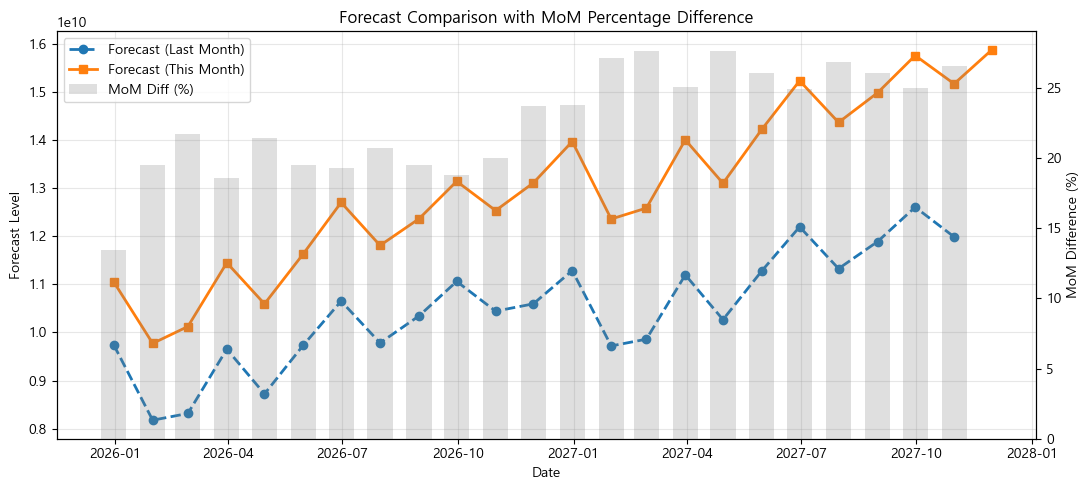

hs_code,Forecast (Last Month),Forecast (This Month),MoM Diff (%)
date,,,
2025-12-31,9.741560e+09,1.105064e+10,13.438104
2026-01-31,8.174686e+09,9.772243e+09,19.542734
2026-02-28,8.314939e+09,1.012278e+10,21.742129
2026-03-31,9.652466e+09,1.144964e+10,18.618803
2026-04-30,8.721463e+09,1.059402e+10,21.470715
2026-05-31,9.738258e+09,1.163905e+10,19.518817
2026-06-30,1.065138e+10,1.270374e+10,19.268502
2026-07-31,9.782411e+09,1.180984e+10,20.725218
2026-08-31,1.034343e+10,1.236403e+10,19.535089


In [48]:
# 1) 컬럼 이름 변경
recent = recent_forecast.rename(columns={'854232': 'Forecast (Last Month)'}).sort_index()
current = last_forecast.rename(columns={'854232': 'Forecast (This Month)'}).sort_index()

# 2) 병합
df_plot = recent.join(current, how='outer')

# 3) 전월대비 비율차이(%) 계산
df_plot['MoM Diff (%)'] = (
    (df_plot['Forecast (This Month)'] - df_plot['Forecast (Last Month)'])
    / df_plot['Forecast (Last Month)']
) * 100

# 4) Figure / 1차 y축 (선)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    df_plot.index,
    df_plot['Forecast (Last Month)'],
    linestyle='--',
    marker='o',
    linewidth=2,
    label='Forecast (Last Month)'
)

ax1.plot(
    df_plot.index,
    df_plot['Forecast (This Month)'],
    linestyle='-',
    marker='s',
    linewidth=2,
    label='Forecast (This Month)'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Forecast Level')
ax1.grid(True, alpha=0.3)

# 2차 y축 (% 막대)
ax2 = ax1.twinx()

ax2.bar(
    df_plot.index,
    df_plot['MoM Diff (%)'],
    color='gray',     # ✅ 회색
    alpha=0.25,       # ✅ 연하게
    width=20,
    label='MoM Diff (%)'
)

ax2.set_ylabel('MoM Difference (%)')

ax2.set_ylabel('MoM Difference (%)')

# 6) 범례 통합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.title('Forecast Comparison with MoM Percentage Difference')
plt.tight_layout()
plt.show()

# (선택) 데이터 확인
display(df_plot)

In [45]:
last_forecast

hs_code,854232
date,
2025-12-31,1.105064e+10
2026-01-31,9.772243e+09
2026-02-28,1.012278e+10
2026-03-31,1.144964e+10
2026-04-30,1.059402e+10
2026-05-31,1.163905e+10
2026-06-30,1.270374e+10
2026-07-31,1.180984e+10
2026-08-31,1.236403e+10
